In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
sns.set(style="whitegrid")

df = pd.read_csv("E:\\student_data.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Shape: (120, 10)

Columns: ['Student_ID', 'Name', 'Gender', 'Maths', 'Science', 'English', 'Attendance_Percentage', 'Total', 'Percentage', 'Result']

First 5 Rows:
   Student_ID    Name Gender  Maths  Science  English  Attendance_Percentage  \
0           1    Neha      M     49       58       85                     86   
1           2   Sneha      M     60       74       94                     92   
2           3   Kavya      F     89       34       69                     68   
3           4  Vikram      M     54       43       73                     92   
4           5   Meena      M     76       60       35                     96   

   Total  Percentage Result  
0    192       64.00   Pass  
1    228       76.00   Pass  
2    192       64.00   Pass  
3    170       56.67   Pass  
4    171       57.00   Pass  

Missing Values:
Student_ID               0
Name                     0
Gender                   0
Maths                    0
Science                  0
English                

In [4]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df.ffill(inplace=True)

In [6]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       Student_ID       Maths     Science     English  Attendance_Percentage  \
count  120.000000  120.000000  120.000000  120.000000             120.000000   
mean    60.500000   64.850000   64.816667   63.025000              75.133333   
std     34.785054   20.807097   21.455830   21.390905              15.101858   
min      1.000000   30.000000   30.000000   30.000000              50.000000   
25%     30.750000   46.000000   45.000000   43.750000              62.000000   
50%     60.500000   66.000000   61.500000   59.500000              75.500000   
75%     90.250000   82.250000   85.250000   82.250000              89.000000   
max    120.000000   99.000000   99.000000  100.000000             100.000000   

            Total  Percentage  
count  120.000000  120.000000  
mean   192.691667   64.230167  
std     33.188485   11.062315  
min    107.000000   35.670000  
25%    169.750000   56.585000  
50%    192.000000   64.000000  
75%    216.250000   72.082500  
ma

In [16]:
# FEATURE ENGINEERING
df['Result'] = df['Percentage'].apply(lambda x: 'Pass' if x >= 40 else 'Fail')

# DATA ANALYSIS

# Pass/Fail Rate
pass_rate = (df['Percentage'] >= 40).mean() * 100
fail_rate = 100 - pass_rate

# Subject-wise Performance
subject_performance = df[['Maths','Science','English']].mean().sort_values(ascending=False)

# Attendance vs Performance Correlation
attendance_corr = df[['Attendance_Percentage', 'Percentage']].corr()

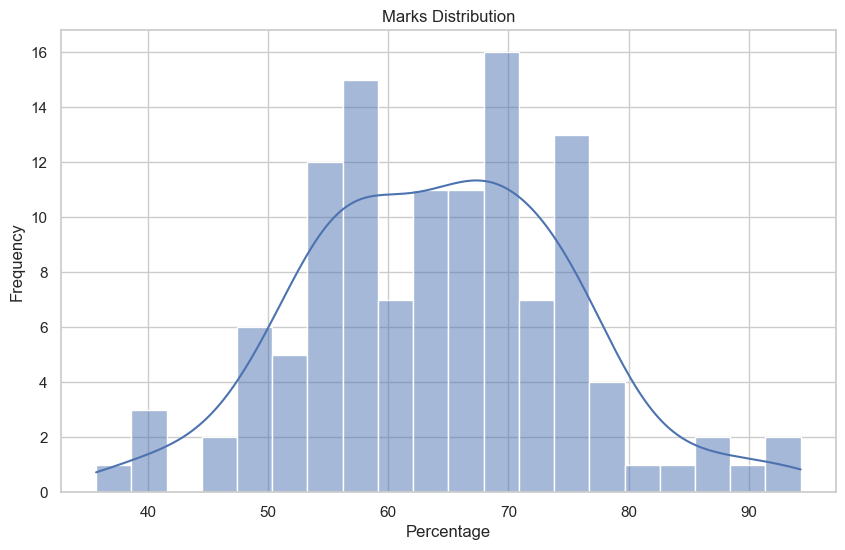

In [17]:
# Histogram - Marks Distribution (use Percentage)
plt.figure()
sns.histplot(df['Percentage'], bins=20, kde=True)
plt.title("Marks Distribution")
plt.xlabel("Percentage")
plt.ylabel("Frequency")
plt.show()

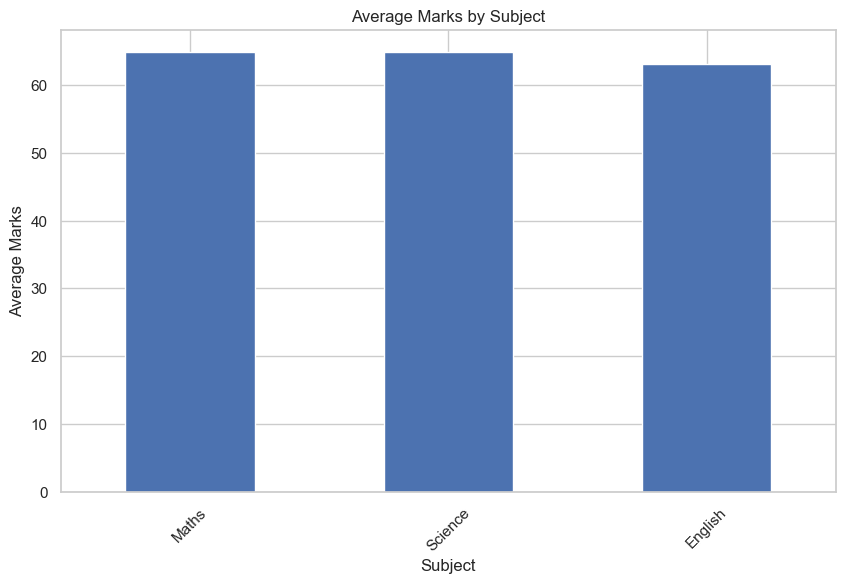

In [18]:
# Bar Chart - Subject Performance
plt.figure()
df[['Maths','Science','English']].mean().plot(kind='bar')
plt.title("Average Marks by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Marks")
plt.xticks(rotation=45)
plt.show()

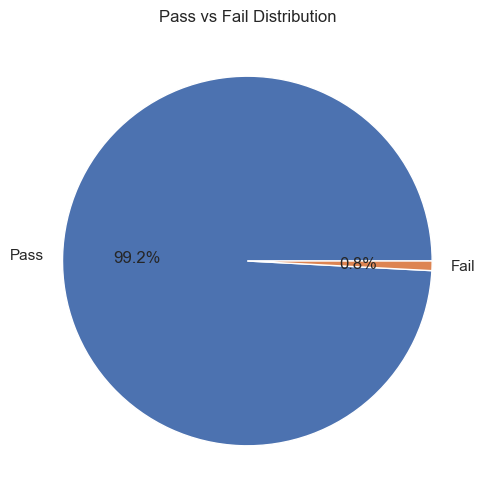

In [19]:
# Pie Chart - Pass vs Fail
plt.figure()
df['Result'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Pass vs Fail Distribution")
plt.ylabel('')
plt.show()

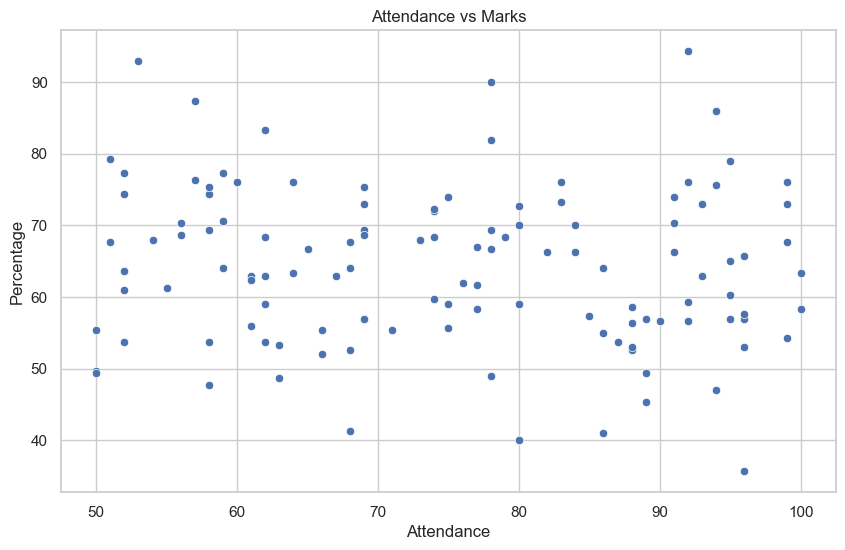

In [20]:
# Scatter Plot - Attendance vs Marks
plt.figure()
sns.scatterplot(x=df['Attendance_Percentage'], y=df['Percentage'])
plt.title("Attendance vs Marks")
plt.xlabel("Attendance")
plt.ylabel("Percentage")
plt.show()


In [21]:
# STATISTICAL ANALYSIS
print("\n📊 Statistical Analysis:")
print("Mean Marks:", df['Percentage'].mean())
print("Median Marks:", df['Percentage'].median())
print("Standard Deviation:", df['Percentage'].std())

print("\nCorrelation Matrix:")
print(df[['Attendance_Percentage', 'Percentage']].corr())


📊 Statistical Analysis:
Mean Marks: 64.23016666666668
Median Marks: 64.0
Standard Deviation: 11.062315315523058

Correlation Matrix:
                       Attendance_Percentage  Percentage
Attendance_Percentage               1.000000   -0.106106
Percentage                         -0.106106    1.000000
